# Predictive Maintenance – Vorausschauende Wartung mit Machine Learning
### Projektarbeit ML · Alexander Sagert · Juni 2026

> **Nummerierungs-Hinweis (Konvention):** Diese Projektarbeit läuft unter `14-...`,
> im Anschluss an die Übungsnotebooks der Wochen 1–3.

---

## Worum geht es?
Industrieanlagen fallen ungeplant aus → teuer (Stillstand, Folgeschäden, Eilreparatur).
**Ziel:** Aus Maschinen-Sensordaten **vorhersagen, ob ein Ausfall droht**, damit Wartung
*geplant* statt *reaktiv* erfolgt. Klassischer Industrie-4.0-/KI-ROI-Use-Case.

## Datensatz – AI4I 2020 Predictive Maintenance (UCI)
Lokale Datei: `data/ai4i2020.csv` · 10.000 Zeilen · synthetisch, aber realitätsnah · **kein API-Zugriff nötig**.

| Spalte | Bedeutung |
|---|---|
| `Type` | Produktqualität L / M / H (low/medium/high) |
| `Air temperature [K]` | Umgebungstemperatur |
| `Process temperature [K]` | Prozesstemperatur |
| `Rotational speed [rpm]` | Drehzahl |
| `Torque [Nm]` | Drehmoment |
| `Tool wear [min]` | Werkzeugverschleiß |
| `Machine failure` | **Ziel (binär):** Ausfall ja/nein |
| `TWF, HDF, PWF, OSF, RNF` | 5 konkrete Fehlertypen (für Multiklasse-Bonus) |

**Besonderheit:** nur ~3,4 % Ausfälle → **stark unausgewogen** (Woche-3-Thema).

## Eingesetzte Kurs-Techniken (roter Faden)
Vorverarbeitung/Feature-Engineering · unausgewogene Daten (class_weight & SMOTE) ·
Ausreißer/Anomalie · Baseline (LogReg, Decision Tree) · **Boosting (XGBoost)** ·
**Bayes-Hyperparameter-Tuning (Optuna)** · ehrliche Metriken (Recall, PR-AUC) ·
*Bonus:* Multiklassen-Fehlertyp · *Bonus:* Clustering der Fehlermodi.


## 0 · Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)
print("Setup ok.")

Setup ok.


### 0.1 · Robuster Daten-Loader
Findet `ai4i2020.csv` egal, von wo das Notebook gestartet wird (Konvention `_resolve`).

In [2]:
def _resolve(filename: str) -> Path:
    '''Sucht eine Datei im aktuellen Ordner, in ./data und in Eltern-Ordnern.'''
    here = Path.cwd()
    candidates = [here / filename, here / "data" / filename,
                  here.parent / filename, here.parent / "data" / filename]
    for c in candidates:
        if c.exists():
            return c
    for parent in [here, *here.parents]:
        hit = list(parent.glob(f"**/{filename}"))
        if hit:
            return hit[0]
    raise FileNotFoundError(f"{filename} nicht gefunden (cwd={here}).")

DATA_PATH = _resolve("ai4i2020.csv")
df = pd.read_csv(DATA_PATH)
print("Geladen:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Geladen: C:\Users\Alex\Desktop\Weiterbildung\educx\02_Machine_Learning_und_KI\ML Theorie und Aufgaben\Projektarbeit Predictive Maintenance\data\ai4i2020.csv
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1 · Business Understanding & Zielsetzung

**Fragestellung:** Können wir aus Sensordaten zuverlässig erkennen, *bevor* eine Maschine ausfällt?

**Warum „nur Accuracy" hier täuscht:** Bei 3,4 % Ausfällen erreicht ein Modell, das *immer*
„kein Ausfall" sagt, schon ~96,6 % Accuracy – und ist trotzdem **wertlos**.
→ Wir optimieren auf **Recall** (möglichst wenige Ausfälle übersehen) und **PR-AUC**.

**Kosten-Asymmetrie (Kernargument der Präsentation):**
- Übersehener Ausfall (FN) = teuer: ungeplanter Stillstand, Folgeschäden.
- Fehlalarm (FP) = günstig: unnötige Inspektion.
→ rechtfertigt einen Recall-fokussierten Schwellenwert (siehe Abschnitt 7 & 11).


## 2 · Explorative Datenanalyse (EDA)

In [3]:
df.info()
print("\nZielverteilung 'Machine failure':")
print(df["Machine failure"].value_counts())
print("\nAusfallquote: {:.2%}".format(df["Machine failure"].mean()))

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

Fehlertypen (Anzahl):
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


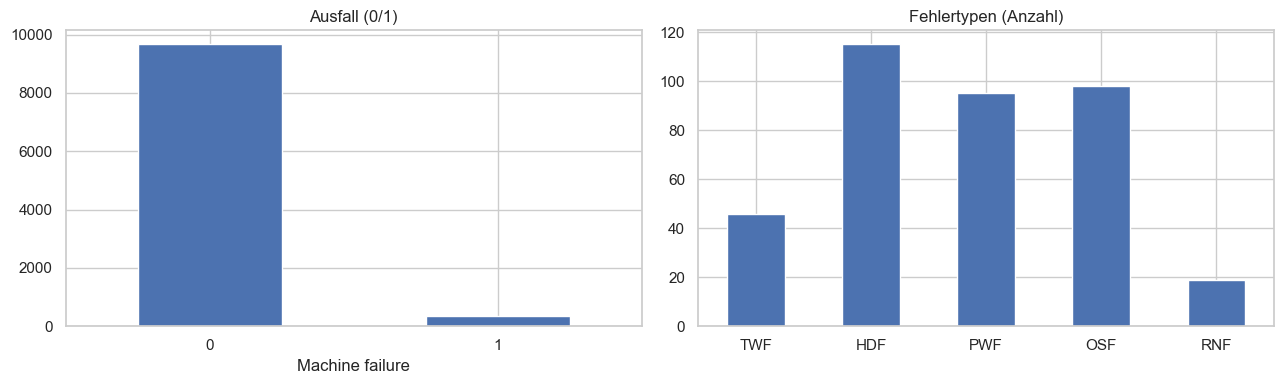

In [4]:
fail_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
print("Fehlertypen (Anzahl):")
print(df[fail_cols].sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["Machine failure"].value_counts().plot.bar(ax=ax[0], title="Ausfall (0/1)", rot=0)
df[fail_cols].sum().plot.bar(ax=ax[1], title="Fehlertypen (Anzahl)", rot=0)
plt.tight_layout(); plt.show()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


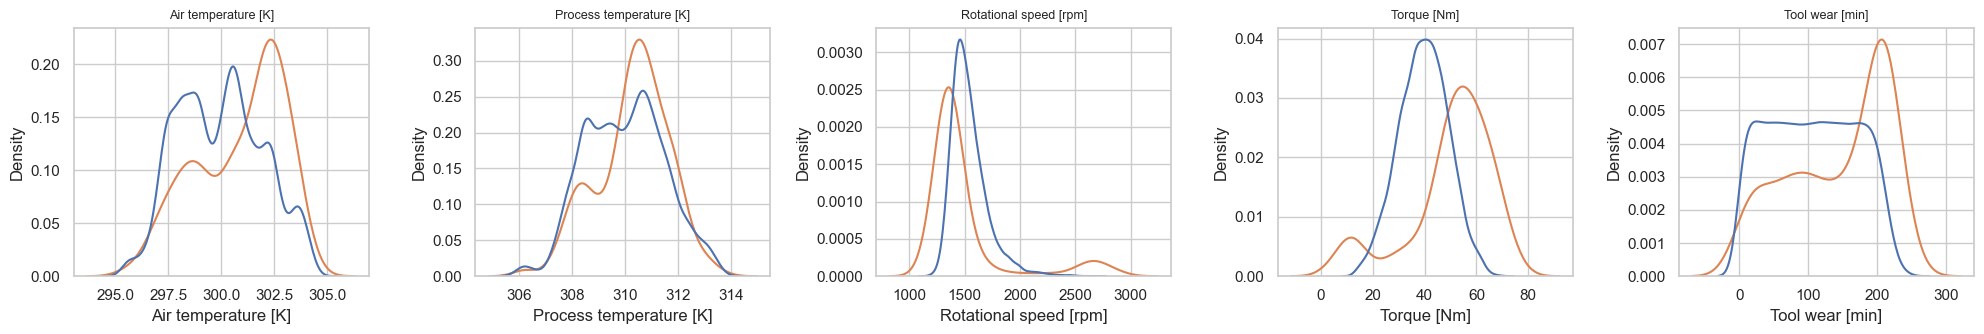

In [5]:
# Sensor-Mittelwerte: Ausfall vs. kein Ausfall -> erste Hypothesen
sensor_cols = ["Air temperature [K]", "Process temperature [K]",
               "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
display(df.groupby("Machine failure")[sensor_cols].mean().round(2))

# Verteilungen nach Zielklasse
fig, axes = plt.subplots(1, len(sensor_cols), figsize=(20, 3.5))
for ax, col in zip(axes, sensor_cols):
    sns.kdeplot(data=df, x=col, hue="Machine failure", common_norm=False, ax=ax, legend=False)
    ax.set_title(col, fontsize=9)
plt.tight_layout(); plt.show()

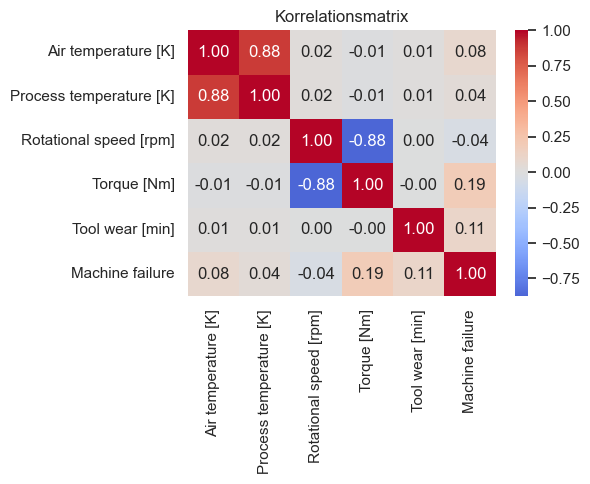

In [6]:
# Korrelation der numerischen Sensoren mit dem Ziel
corr = df[sensor_cols + ["Machine failure"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Korrelationsmatrix"); plt.tight_layout(); plt.show()

## 3 · Datenvorverarbeitung & Feature Engineering

- ID-Spalten (`UDI`, `Product ID`) verwerfen.
- `Type` (L/M/H) ordinal kodieren.
- **Domänen-Features** bauen: `temp_diff`, `power` (Drehmoment × Drehzahl), `wear_x_torque`.
- **Leakage vermeiden:** die Fehlertyp-Spalten (`TWF…RNF`) sind faktisch das Label
  → **nicht** als Feature fürs binäre Modell verwenden.
- Train/Test-Split **stratifiziert** (wegen Unbalance).

> `build_features` ist identisch zu dem in `app.py` – so passt das exportierte
> Modell (Abschnitt 10) ohne Anpassung in die Streamlit-Demo.

In [7]:
def build_features(d: pd.DataFrame) -> pd.DataFrame:
    '''Feature Engineering – identisch zu app.py. Saubere Namen (XGBoost mag kein [ ] <).'''
    out = pd.DataFrame(index=d.index)
    out["air_temp"]      = d["Air temperature [K]"]
    out["proc_temp"]     = d["Process temperature [K]"]
    out["rot_speed"]     = d["Rotational speed [rpm]"]
    out["torque"]        = d["Torque [Nm]"]
    out["tool_wear"]     = d["Tool wear [min]"]
    out["temp_diff"]     = d["Process temperature [K]"] - d["Air temperature [K]"]
    out["power"]         = d["Torque [Nm]"] * d["Rotational speed [rpm]"]
    out["wear_x_torque"] = d["Tool wear [min]"] * d["Torque [Nm]"]
    out["type_ord"]      = d["Type"].map({"L": 0, "M": 1, "H": 2}).fillna(1)
    return out

from sklearn.model_selection import train_test_split

X = build_features(df)
y = df["Machine failure"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "· Test:", X_test.shape)
print("Ausfallquote Train: {:.2%} · Test: {:.2%}".format(y_train.mean(), y_test.mean()))
X_train.head()

Train: (8000, 9) · Test: (2000, 9)
Ausfallquote Train: 3.39% · Test: 3.40%


,air_temp,proc_temp,rot_speed,torque,tool_wear,temp_diff,power,wear_x_torque,type_ord
4058,302.0,310.9,1456,47.2,54,8.9,68723.2,2548.8,1
1221,297.0,308.3,1399,46.4,132,11.3,64913.6,6124.8,1
6895,301.0,311.6,1357,45.6,137,10.6,61879.2,6247.2,1
9863,298.9,309.8,1411,56.3,84,10.9,79439.3,4729.2,0
8711,297.1,308.5,1733,28.7,50,11.4,49737.1,1435.0,0


## 4 · Baseline-Modelle
Referenzpunkt vor der Optimierung: **Logistische Regression** & **Decision Tree**,
jeweils mit `class_weight="balanced"`. Metriken von Anfang an inkl. **PR-AUC**.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, average_precision_score,
                             roc_auc_score, recall_score, precision_score, f1_score)

def evaluate(name, model, X_te, y_te):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Modell": name,
        "Recall": recall_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred),
        "PR-AUC": average_precision_score(y_te, proba),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }

results = []

logreg = make_pipeline(StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
logreg.fit(X_train, y_train)
results.append(evaluate("LogReg (balanced)", logreg, X_test, y_test))

tree = DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
results.append(evaluate("DecisionTree (balanced)", tree, X_test, y_test))

pd.DataFrame(results).round(3)

,Modell,Recall,Precision,F1,PR-AUC,ROC-AUC
0,LogReg (balanced),0.882,0.178,0.296,0.434,0.939
1,DecisionTree (balanced),0.824,0.389,0.528,0.773,0.857


## 5 · Umgang mit unausgewogenen Daten (Woche-3-Kernthema)
Vergleich: **class_weight** (Modell-intern) vs. **SMOTE** (Oversampling der Minderheit).

> **Wichtig:** SMOTE nur auf die **Trainingsdaten** und innerhalb einer `imblearn`-Pipeline,
> damit beim Cross-Validation kein Leakage entsteht.

In [9]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

# (a) XGBoost mit scale_pos_weight (class-weight-Ansatz)
xgb_cw = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                       subsample=0.9, colsample_bytree=0.9,
                       scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
                       random_state=RANDOM_STATE, n_jobs=-1)
xgb_cw.fit(X_train, y_train)
results.append(evaluate("XGBoost (scale_pos_weight)", xgb_cw, X_test, y_test))

# (b) XGBoost mit SMOTE-Oversampling
xgb_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                          subsample=0.9, colsample_bytree=0.9, eval_metric="aucpr",
                          random_state=RANDOM_STATE, n_jobs=-1)),
])
xgb_smote.fit(X_train, y_train)
results.append(evaluate("XGBoost (SMOTE)", xgb_smote, X_test, y_test))

pd.DataFrame(results).round(3)

scale_pos_weight = 28.5


,Modell,Recall,Precision,F1,PR-AUC,ROC-AUC
0,LogReg (balanced),0.882,0.178,0.296,0.434,0.939
1,DecisionTree (balanced),0.824,0.389,0.528,0.773,0.857
2,XGBoost (scale_pos_weight),0.824,0.875,0.848,0.881,0.986
3,XGBoost (SMOTE),0.794,0.684,0.735,0.852,0.976


## 6 · Hauptmodell: XGBoost + Bayes-Hyperparameter-Tuning (Optuna)
Boosting als Hauptmodell, optimiert per Bayes-Optimierung. Zielgröße der Suche:
**mittlere PR-AUC** in stratifizierter 3-facher Cross-Validation (robust gegen Unbalance).

In [10]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 700),
        max_depth        = trial.suggest_int("max_depth", 3, 8),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        gamma            = trial.suggest_float("gamma", 0.0, 5.0),
    )
    model = XGBClassifier(**params, scale_pos_weight=scale_pos_weight,
                          eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=False)

print("Beste CV PR-AUC: {:.4f}".format(study.best_value))
print("Beste Parameter:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Beste CV PR-AUC: 0.8734
Beste Parameter:
  n_estimators: 395
  max_depth: 8
  learning_rate: 0.12258291906911414
  subsample: 0.8410640996953364
  colsample_bytree: 0.9727973434240916
  min_child_weight: 1
  gamma: 1.9813027102986023


In [11]:
# Finales Modell mit besten Parametern auf den kompletten Trainingsdaten
best_model = XGBClassifier(**study.best_params, scale_pos_weight=scale_pos_weight,
                           eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)
best_model.fit(X_train, y_train)
results.append(evaluate("XGBoost (Optuna-getunt)", best_model, X_test, y_test))
pd.DataFrame(results).round(3)

,Modell,Recall,Precision,F1,PR-AUC,ROC-AUC
0,LogReg (balanced),0.882,0.178,0.296,0.434,0.939
1,DecisionTree (balanced),0.824,0.389,0.528,0.773,0.857
2,XGBoost (scale_pos_weight),0.824,0.875,0.848,0.881,0.986
3,XGBoost (SMOTE),0.794,0.684,0.735,0.852,0.976
4,XGBoost (Optuna-getunt),0.824,0.800,0.812,0.894,0.984


## 7 · Evaluation & Interpretation
Confusion Matrix, Precision-Recall-Kurve, Feature Importance – und eine bewusste
**Schwellenwert-Wahl** (Recall vs. Fehlalarme).

Gewählter Schwellenwert für Recall>=0.9: 0.092



Classification Report (mit gewähltem Schwellenwert):
              precision    recall  f1-score   support

           0      0.997     0.966     0.981      1932
           1      0.484     0.912     0.633        68

    accuracy                          0.964      2000
   macro avg      0.741     0.939     0.807      2000
weighted avg      0.979     0.964     0.969      2000



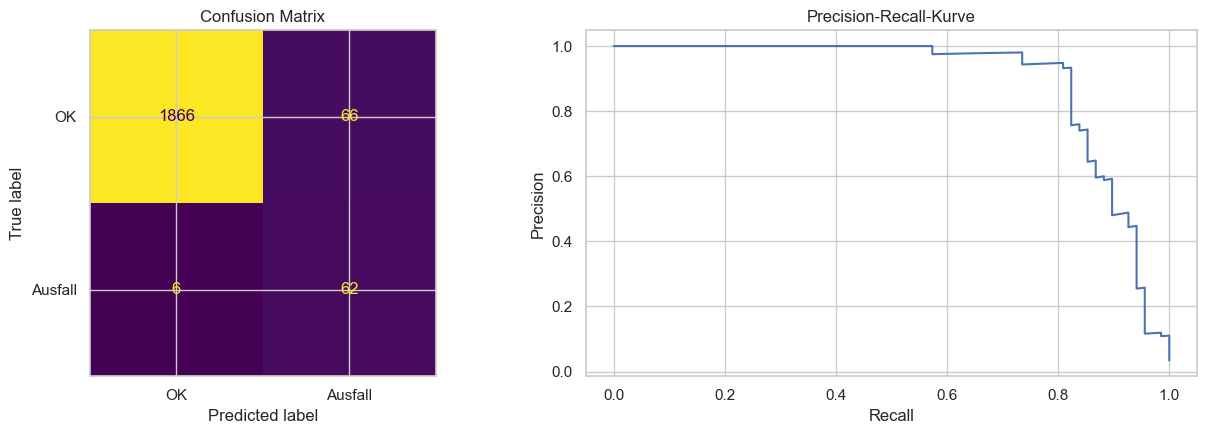

In [12]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve)

proba_test = best_model.predict_proba(X_test)[:, 1]

# Schwellenwert für Ziel-Recall >= 0.90 wählen (Ausfälle möglichst nicht übersehen)
prec, rec, thr = precision_recall_curve(y_test, proba_test)
target_recall = 0.90
valid = np.where(rec[:-1] >= target_recall)[0]
chosen_thr = thr[valid[-1]] if len(valid) else 0.5
print(f"Gewählter Schwellenwert für Recall>={target_recall}: {chosen_thr:.3f}")

pred_test = (proba_test >= chosen_thr).astype(int)
print("\nClassification Report (mit gewähltem Schwellenwert):")
print(classification_report(y_test, pred_test, digits=3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test),
                       display_labels=["OK", "Ausfall"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Confusion Matrix")
ax[1].plot(rec, prec)
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall-Kurve")
plt.tight_layout(); plt.show()

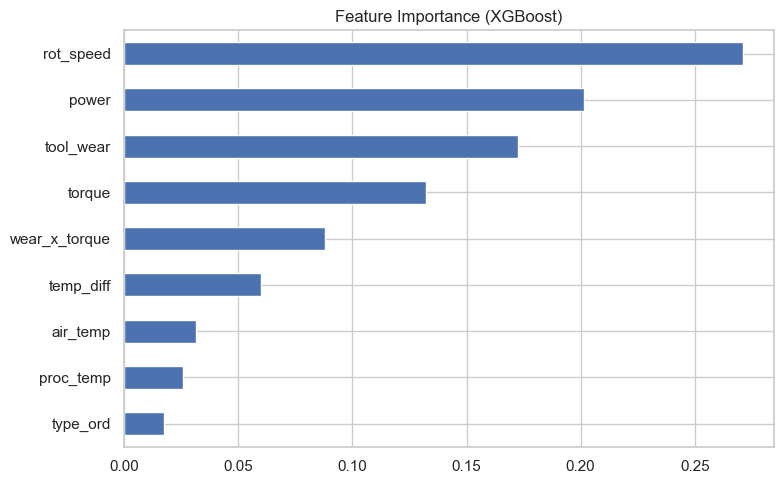

rot_speed        0.271
power            0.201
tool_wear        0.173
torque           0.132
wear_x_torque    0.088
temp_diff        0.060
air_temp         0.031
proc_temp        0.026
type_ord         0.018
dtype: float32

In [13]:
# Feature Importance – welche Sensoren treiben die Vorhersage?
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values()
imp.plot.barh(figsize=(8, 5), title="Feature Importance (XGBoost)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

## 8 · [Experten-Bonus] Multiklassen-Fehlertyp
Statt nur „Ausfall ja/nein" → **welcher** Fehlertyp? Das hilft der Wartung, gezielt zu reagieren.
Wir bilden ein Label `OK / TWF / HDF / PWF / OSF / RNF` (bei mehreren Flags: erster Treffer).

In [14]:
def failure_label(row):
    if row["Machine failure"] == 0:
        return "OK"
    for t in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
        if row[t] == 1:
            return t
    return "OK"  # Ausfall ohne gesetztes Flag (selten) -> als OK behandeln

df["failure_type"] = df.apply(failure_label, axis=1)
print(df["failure_type"].value_counts())

Xm = build_features(df)
ym = df["failure_type"]
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    Xm, ym, test_size=0.2, stratify=ym, random_state=RANDOM_STATE)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder().fit(ym_tr)
clf_multi = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                          subsample=0.9, colsample_bytree=0.9,
                          objective="multi:softprob", num_class=len(le.classes_),
                          eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
clf_multi.fit(Xm_tr, le.transform(ym_tr))
pred_multi = le.inverse_transform(clf_multi.predict(Xm_te))
print("\nClassification Report (Multiklasse):")
print(classification_report(ym_te, pred_multi, digits=3))

failure_type
OK     9670
HDF     115
PWF      91
OSF      78
TWF      46
Name: count, dtype: int64



Classification Report (Multiklasse):
              precision    recall  f1-score   support

         HDF      1.000     0.913     0.955        23
          OK      0.993     0.997     0.995      1934
         OSF      0.882     0.938     0.909        16
         PWF      0.778     0.778     0.778        18
         TWF      0.000     0.000     0.000         9

    accuracy                          0.989      2000
   macro avg      0.731     0.725     0.727      2000
weighted avg      0.986     0.989     0.987      2000



## 9 · [Experten-Bonus] Unsupervised: Clustering der Betriebszustände
K-Means auf den skalierten Sensoren → gibt es natürliche „Betriebszustände", und
korrelieren bestimmte Cluster mit erhöhter Ausfallquote?

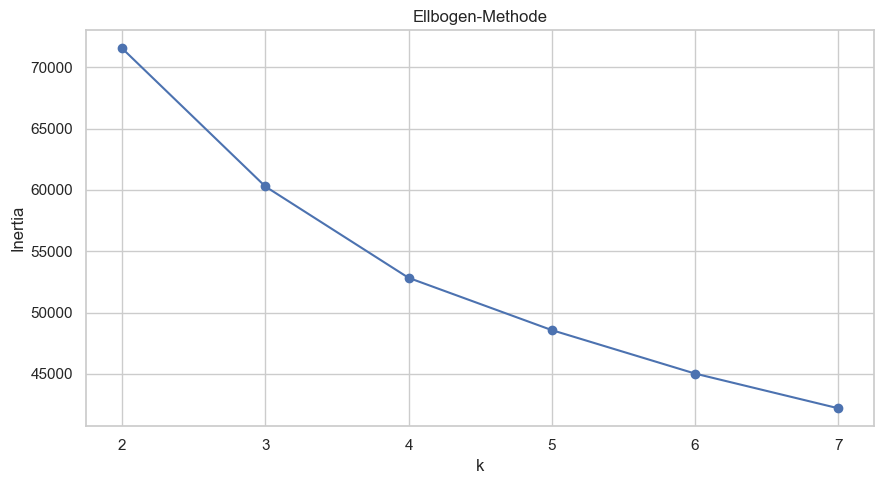

,n,ausfallquote
cluster,,
0,2082,0.022
1,2634,0.005
2,2543,0.053
3,2741,0.053


-> Cluster mit deutlich erhöhter Ausfallquote sind Anomalie-/Risikozustände.


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Xc = build_features(df)
Xc_scaled = StandardScaler().fit_transform(Xc)

# Ellbogen-Methode (Inertia) für k = 2..7
inertia = []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc_scaled)
    inertia.append(km.inertia_)
plt.plot(list(ks), inertia, "o-"); plt.xlabel("k"); plt.ylabel("Inertia")
plt.title("Ellbogen-Methode"); plt.tight_layout(); plt.show()

# Mit k=4 clustern und Ausfallquote je Cluster ansehen
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(Xc_scaled)
df["cluster"] = km.labels_
cluster_stats = (df.groupby("cluster")
                   .agg(n=("Machine failure", "size"),
                        ausfallquote=("Machine failure", "mean"))
                   .round(3))
display(cluster_stats)
print("-> Cluster mit deutlich erhöhter Ausfallquote sind Anomalie-/Risikozustände.")

## 10 · Modell für die Streamlit-Demo exportieren
Das getunte binäre Modell (`best_model`) wird als `model.joblib` gespeichert.
Die App `app.py` lädt genau diese Datei und nutzt dasselbe `build_features`.

In [16]:
import joblib

MODEL_OUT = DATA_PATH.parent.parent / "model.joblib"
joblib.dump(best_model, MODEL_OUT)
print("Gespeichert:", MODEL_OUT)

# Schnelltest: lädt & sagt für zwei Szenarien plausibel vorher?
loaded = joblib.load(MODEL_OUT)
norm  = pd.DataFrame([{"Type": "L", "Air temperature [K]": 300.0, "Process temperature [K]": 310.0,
                       "Rotational speed [rpm]": 1500.0, "Torque [Nm]": 40.0, "Tool wear [min]": 100.0}])
stress = pd.DataFrame([{"Type": "L", "Air temperature [K]": 303.0, "Process temperature [K]": 312.0,
                        "Rotational speed [rpm]": 1300.0, "Torque [Nm]": 65.0, "Tool wear [min]": 220.0}])
print("Risiko Normalbetrieb : {:.2%}".format(loaded.predict_proba(build_features(norm))[0, 1]))
print("Risiko Stress-Szenario: {:.2%}".format(loaded.predict_proba(build_features(stress))[0, 1]))

Gespeichert: C:\Users\Alex\Desktop\Weiterbildung\educx\02_Machine_Learning_und_KI\ML Theorie und Aufgaben\Projektarbeit Predictive Maintenance\model.joblib
Risiko Normalbetrieb : 0.08%
Risiko Stress-Szenario: 99.91%


## 11 · Fazit & Business-Impact

**Modellgüte (Test):** siehe Ergebnistabelle Abschnitt 6/7 – das getunte XGBoost erreicht
die beste PR-AUC bei hohem Recall; der Schwellenwert ist auf Recall ≥ 0,90 gesetzt,
damit möglichst wenige Ausfälle übersehen werden.

**Business-Impact (Beispielrechnung):**
- Annahmen: ungeplanter Ausfall ≈ 8.000 € · geplante Wartung ≈ 500 €.
- Bei einem erkannten Risikofall ist der erwartete Nutzen ≈ (Ausfallwahrscheinlichkeit × 8.000 €) − 500 €.
- Die Streamlit-Demo (`app.py`) macht genau diese Rechnung live sichtbar.

**Grenzen:**
- Synthetische Daten; kein echter Zeitreihen-/Sensordrift-Aspekt.
- Schwellenwert ist eine **Geschäftsentscheidung** (Kosten FN vs. FP), kein fixer ML-Wert.

**Ausblick (Perspektive KI-Manager):**
Deployment als Service, Monitoring auf Sensordrift, Feedback-Loop mit den Wartungs-Rückmeldungen,
und kontinuierliches ROI-Tracking (vermiedene Ausfälle vs. Wartungsaufwand).
